# 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import warnings
import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from collections import Counter

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

pd.set_option("display.max_colwidth", 200)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

warnings.filterwarnings("ignore")

### W&B login

In [2]:
!pip install -q wandb

import wandb

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=secret_value_0)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# 2. Data Loading & EDA

### Load train/test

In [4]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (2000, 8)
Test Shape: (500, 7)


### Inspect sample questions

In [5]:
for i in range(3):
    print("="*80)
    print(train.loc[i,"prompt"])

    for opt in ["A","B","C","D","E"]:
        print(f"{opt}: {train.loc[i,opt]}")

    print("Answer:", train.loc[i,"answer"])

Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
B: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
C: Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.
D: Martin Heidegger believes that the relationship between

### Missing values check

In [6]:
train.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [7]:
train["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

### Answer distribution

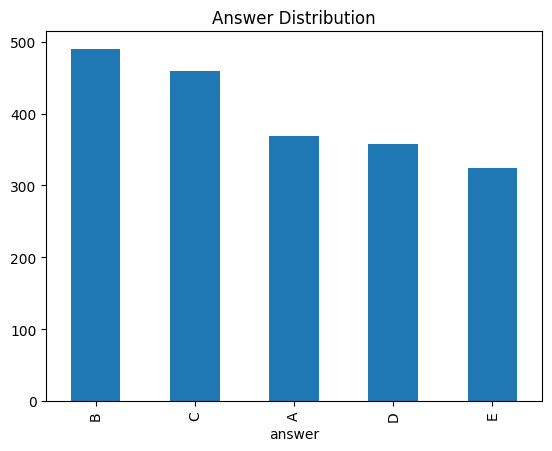

In [8]:
train["answer"].value_counts().plot(kind="bar")
plt.title("Answer Distribution")
plt.show()

### Prompt / option length stats

In [9]:
train["prompt_len"] = train["prompt"].astype(str).apply(len)

train["prompt_len"].describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_len, dtype: float64

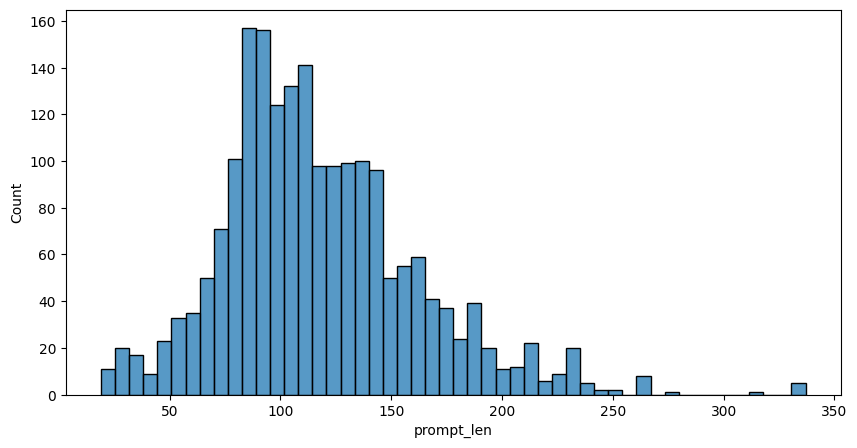

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(train["prompt_len"], bins=50)
plt.show()

### Duplicate-question analysis


In [11]:
for col in ["A","B","C","D","E"]:
    train[f"{col}_len"] = train[col].astype(str).apply(len)

train[[f"{c}_len" for c in ["A","B","C","D","E"]]].describe()

,A_len,B_len,C_len,D_len,E_len
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,164.091500,166.616500,167.227000,162.56350,164.230000
std,105.677145,113.829917,105.723674,104.11657,107.777712
min,1.000000,2.000000,2.000000,1.00000,2.000000
25%,86.000000,82.000000,88.000000,91.00000,84.000000
50%,143.000000,151.000000,158.000000,141.00000,144.000000
75%,234.000000,222.000000,224.000000,231.00000,224.000000
max,472.000000,662.000000,530.000000,450.00000,587.000000


In [12]:
train["prompt"].duplicated().sum()

np.int64(242)

In [13]:
dup_prompts = train[train["prompt"].duplicated(keep=False)]

print("Duplicate rows:", len(dup_prompts))

dup_prompts[["prompt","answer"]].head(20)

Duplicate rows: 454


,prompt,answer
0,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,B
3,Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existence? carefully.,B
4,"Identify the correct statement: What is the concept of simultaneity in Einstein's book, Relativity? carefully.",A
5,Identify the correct statement: What is the effect generated by a spinning superconductor? among the listed options.,C
8,Select the most accurate option: What are the constituents of cold dark matter?,A
20,Identify the correct statement: What is the reason that it is nearly impossible to see light emitted at the Lyman-alpha transition wavelength from a star farther than a few hundred light years fro...,B
23,Which of the following is correct? Which of the following statements accurately describes the blocking temperature of an antiferromagnetic layer in a spin valve? carefully.,D
27,Identify the correct statement: What is a uniform tiling in the hyperbolic plane? based on the given context.,D
35,Determine the correct option: What is the purpose of the proximity-focusing design in a RICH detector? from the following choices.,D
42,Choose the correct answer: What are permutation-inversion groups? based on the given context.,E


In [14]:
dup_answer_check = (
    train.groupby("prompt")["answer"]
    .nunique()
    .reset_index()
)

dup_answer_check = dup_answer_check[dup_answer_check["answer"] > 1]

print("Duplicate prompts with multiple answers:")
print(len(dup_answer_check))

Duplicate prompts with multiple answers:
0


In [15]:
train["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

In [16]:
train["prompt_len"] = train["prompt"].astype(str).apply(len)

train["prompt_len"].describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_len, dtype: float64

### Binary-pair builder (used by the TF-IDF baseline)
Converts each (question, 5 options) row into 5 separate
(prompt, candidate) -> is_correct text pairs, for the baseline classifier.

In [17]:
def build_train_data(df):

    texts = []
    labels = []

    for _, row in df.iterrows():

        for option in ["A","B","C","D","E"]:

            text = (
                f"Question: {row['prompt']} "
                f"Candidate Answer: {row[option]}"
            )

            texts.append(text)

            labels.append(
                1 if row["answer"] == option else 0
            )

    return texts, labels

# 3. Baseline Model – TF-IDF + Logistic Regression

### Train/val split

In [18]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train["answer"]
)

train_texts, train_labels = build_train_data(train_df)

print(len(train_texts))
print(len(train_labels))

8000
8000


### TF-IDF vectorization


In [19]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_texts)

### Logistic Regression baseline


In [20]:
model = LogisticRegression(
    max_iter=2000,
    C=3.0,
    class_weight="balanced"
)

model.fit(X_train, train_labels)

print("Training Complete")

Training Complete


### MAP@3 metric functions
apk/mapk: standard Average-Precision-at-K and Mean-Average-Precision-at-K,
matching the competition's evaluation metric.

In [21]:
def apk(actual,predicted,k=3):

    predicted = predicted[:k]

    try:
        return 1.0 / (
            predicted.index(actual) + 1
        )

    except ValueError:

        return 0.0

In [22]:
def mapk(
    actuals,
    predictions,
    k=3
):

    scores = []

    for a,p in zip(
        actuals,
        predictions
    ):

        scores.append(
            apk(a,p,k)
        )

    return np.mean(scores)

In [23]:
# tfidf_map3 = mapk(
#     actual_answers,
#     predictions,
#     k=3
# )

# print("Validation MAP@3:", tfidf_map3)

# wandb.log({
#     "Validation MAP@3": tfidf_map3
# })

### Test-set inference


In [24]:
test_texts = []

for _, row in test.iterrows():

    for option in ["A","B","C","D","E"]:

        text = (
            f"Question: {row['prompt']} "
            f"Candidate Answer: {row[option]}"
        )

        test_texts.append(text)

print(len(test_texts))

2500


In [25]:
X_test = vectorizer.transform(test_texts)

tfidf_probs = model.predict_proba(X_test)[:,1]

# Model 1 — Custom Transformer (Built from Scratch)

### Imports and hyperparameters


In [26]:
import gc
import math
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold

from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


In [27]:
MAX_LENGTH = 256
VOCAB_SIZE = 30000
EMBED_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 4
FF_DIM = 512
DROPOUT = 0.2

BATCH_SIZE = 32
LEARNING_RATE = 3e-4
EPOCHS = 22
NUM_FOLDS = 5
SEED = 42

TRAIN_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
TEST_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
OUTPUT_DIR = "/kaggle/working/"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHOICES = ['A', 'B', 'C', 'D', 'E']

print(f"Config: embed={EMBED_DIM}, heads={NUM_HEADS}, layers={NUM_LAYERS}")

Config: embed=256, heads=8, layers=4


In [28]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)

In [29]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
print(f"Train: {train.shape}, Test: {test.shape}")

Train: (2000, 8), Test: (500, 7)


### Simple tokenizer


In [30]:
# Simple tokenizer from scratch
import re

class SimpleTokenizer:
    def __init__(self, vocab_size=30000):
        self.vocab_size = vocab_size
        self.word2idx = {"[PAD]": 0, "[UNK]": 1, "[CLS]": 2, "[SEP]": 3}
        self.idx2word = {0: "[PAD]", 1: "[UNK]", 2: "[CLS]", 3: "[SEP]"}
        self.next_idx = 4
    
    def tokenize(self, text):
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s]', ' ', text)
        return text.split()
    
    def build_vocab(self, texts):
        word_counts = Counter()
        for text in texts:
            tokens = self.tokenize(text)
            word_counts.update(tokens)
        
        for word, _ in word_counts.most_common(self.vocab_size - 4):
            if word not in self.word2idx:
                self.word2idx[word] = self.next_idx
                self.idx2word[self.next_idx] = word
                self.next_idx += 1
        
        print(f"Vocab size: {len(self.word2idx)}")
    
    def encode(self, text_a, text_b, max_length):
        tokens_a = self.tokenize(text_a)
        tokens_b = self.tokenize(text_b)
        
        
        tokens = ["[CLS]"] + tokens_a[:max_length//2 - 2] + ["[SEP]"] + tokens_b[:max_length//2 - 1] + ["[SEP]"]
        
        ids = [self.word2idx.get(t, self.word2idx["[UNK]"]) for t in tokens]
        
        
        if len(ids) < max_length:
            attention_mask = [1] * len(ids) + [0] * (max_length - len(ids))
            ids = ids + [0] * (max_length - len(ids))
        else:
            ids = ids[:max_length]
            attention_mask = [1] * max_length
        
        return ids, attention_mask

### Build vocabulary


In [31]:
all_texts = []
for _, row in train.iterrows():
    all_texts.append(str(row["prompt"]))
    for c in CHOICES:
        all_texts.append(str(row[c]))

for _, row in test.iterrows():
    all_texts.append(str(row["prompt"]))
    for c in CHOICES:
        all_texts.append(str(row[c]))

tokenizer = SimpleTokenizer(vocab_size=VOCAB_SIZE)
tokenizer.build_vocab(all_texts)

Vocab size: 2977


### Binary-pair dataset construction


In [32]:
def create_binary_df(df, has_answer=True):
    rows = []
    for _, row in df.iterrows():
        for choice in CHOICES:
            rows.append({
                "id": row["id"],
                "prompt": row["prompt"],
                "candidate": row[choice],
                "choice": choice,
                "label": int(choice == row["answer"]) if has_answer else None
            })
    return pd.DataFrame(rows)

binary_train = create_binary_df(train, has_answer=True)
binary_test = create_binary_df(test, has_answer=False)

print(f"Binary train: {binary_train.shape}")
print(f"Binary test: {binary_test.shape}")

Binary train: (10000, 5)
Binary test: (2500, 5)


### PyTorch Dataset class


In [33]:
class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, is_test=False):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        text_a = str(row["prompt"])
        text_b = f"{row['choice']} {row['candidate']}"
        
        ids, mask = self.tokenizer.encode(text_a, text_b, self.max_len)
        
        result = {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "attention_mask": torch.tensor(mask, dtype=torch.long),
        }
        if not self.is_test:
            result["labels"] = torch.tensor(row["label"], dtype=torch.long)
        return result

### Positional encoding
Standard sinusoidal positional encoding module.

In [34]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

### Transformer encoder layer (from scratch)

In [35]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.activation = nn.GELU()
    
    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        
        src2, _ = self.self_attn(src, src, src, key_padding_mask=src_key_padding_mask)
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        

        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        
        return src

### Full Transformer classifier


In [36]:
# Full Transformer Model
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, dim_feedforward, num_classes=2, max_len=512, dropout=0.1):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)
        
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )
        
        self.d_model = d_model
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, input_ids, attention_mask):
        # Embedding
        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        
        # Transformer layers
        key_padding_mask = (attention_mask == 0)  # True for padding
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=key_padding_mask)
        
        # Pool (mean of non-padding tokens)
        mask_expanded = attention_mask.unsqueeze(-1).float()
        sum_embeddings = (x * mask_expanded).sum(1)
        sum_mask = mask_expanded.sum(1).clamp(min=1e-9)
        pooled = sum_embeddings / sum_mask
        
        # Classification
        logits = self.fc(pooled)
        return logits

# Test model
model = TransformerClassifier(
    vocab_size=len(tokenizer.word2idx),
    d_model=EMBED_DIM,
    nhead=NUM_HEADS,
    num_layers=NUM_LAYERS,
    dim_feedforward=FF_DIM,
    max_len=MAX_LENGTH,
    dropout=DROPOUT
)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
del model

Model parameters: 2,936,834


### Train/eval loop functions


In [37]:
def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    
    for batch in tqdm(loader, desc="Train", leave=False):
        optimizer.zero_grad()
        
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    probs = []
    for batch in tqdm(loader, desc="Eval", leave=False):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        
        logits = model(input_ids, attention_mask)
        batch_probs = F.softmax(logits, dim=1)[:, 1]
        probs.extend(batch_probs.cpu().numpy())
    return np.array(probs)


def calc_map3(df, probs):
    df = df.copy()
    df["prob"] = probs
    scores = []
    for _, g in df.groupby("id"):
        g = g.sort_values("prob", ascending=False)
        pred = g["choice"].tolist()[:3]
        true = g[g["label"] == 1]["choice"].iloc[0]
        score = 0
        for i, p in enumerate(pred):
            if p == true:
                score = 1 / (i + 1)
                break
        scores.append(score)
    return np.mean(scores)

### W&B run init (Transformer)


In [38]:
wandb.init(
    project="dl-22f3000356-notebook-t22026",
    entity="22f3000356-indian-institute-of-technology-madras",
    name="transformer-LR1e-5",
    tags=["transformer", "scratch", "baseline"],
    config={
        "model": "Custom Transformer",
        "embedding_dim": EMBED_DIM,
        "num_heads": NUM_HEADS,
        "num_layers": NUM_LAYERS,
        "feedforward_dim": FF_DIM,
        "dropout": DROPOUT,
        "learning_rate": 1e-5,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "folds": NUM_FOLDS,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR"
    }
)

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260802_152729-rli2ry8v
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run transformer-LR1e-5
wandb: ⭐️ View project at https://wandb.ai/22f3000356-indian-institute-of-technology-madras/dl-22f3000356-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/22f3000356-indian-institute-of-technology-madras/dl-22f3000356-notebook-t22026/runs/rli2ry8v


### 5-Fold Stratified CV training
Trains the from-scratch Transformer across 5 folds 

In [ ]:
print(f"\n{'='*50}")
print(f"{NUM_FOLDS}-Fold CV | Transformer from Scratch | {EPOCHS} epochs")
print(f"{'='*50}\n")

unique_ids = train["id"].values
labels = train["answer"].values

skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

oof_probs = np.zeros(len(binary_train))
test_probs = np.zeros(len(binary_test))
fold_scores = []

criterion = nn.CrossEntropyLoss()

for fold, (train_idx, val_idx) in enumerate(skf.split(unique_ids, labels)):
    print(f"\n{'='*40}")
    print(f"FOLD {fold+1}/{NUM_FOLDS}")
    print(f"{'='*40}")
    
    train_ids = unique_ids[train_idx]
    val_ids = unique_ids[val_idx]
    
    train_fold = binary_train[binary_train["id"].isin(train_ids)].reset_index(drop=True)
    val_fold = binary_train[binary_train["id"].isin(val_ids)].reset_index(drop=True)
    val_binary_idx = binary_train[binary_train["id"].isin(val_ids)].index.values
    
    print(f"Train: {len(train_fold)}, Val: {len(val_fold)}")
    
    train_dataset = MCQDataset(train_fold, tokenizer, MAX_LENGTH)
    val_dataset = MCQDataset(val_fold, tokenizer, MAX_LENGTH)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)#Training needs backpropagation. Validation does not compute gradients, so it requires less memory. A larger batch size speeds up evaluation.
    
    model = TransformerClassifier(
        vocab_size=len(tokenizer.word2idx),
        d_model=EMBED_DIM,
        nhead=NUM_HEADS,
        num_layers=NUM_LAYERS,
        dim_feedforward=FF_DIM,
        max_len=MAX_LENGTH,
        dropout=DROPOUT
    )
    model.to(DEVICE)
        
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    total_steps = EPOCHS * len(train_loader)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    
    best_map3 = 0
    best_state = None
    best_val_probs = None
    
    patience = 4
    no_improve = 0
    
    for epoch in range(EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion)
        val_probs_epoch = get_probs(model, val_loader)
        val_preds = (val_probs_epoch >= 0.5).astype(int)
        val_labels = val_fold["label"].values
        
        accuracy = accuracy_score(val_labels, val_preds)
        f1 = f1_score(val_labels, val_preds)
        val_map3 = calc_map3(val_fold, val_probs_epoch)

        wandb.log({
            "Fold": fold + 1,
            "Epoch": epoch + 1,
            "Training Loss": train_loss,
            "Validation Accuracy": accuracy,
            "Validation F1": f1,
            "Validation MAP@3": val_map3,
            "Best MAP@3 So Far": max(best_map3, val_map3),
            "Learning Rate": optimizer.param_groups[0]["lr"]
        })     
        print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, MAP@3={val_map3:.4f}", end="")
        
        if val_map3 > best_map3:
            best_map3 = val_map3
            best_val_probs = val_probs_epoch.copy()
        
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
        
            no_improve = 0
            print(" *")
        else:
            no_improve += 1
            print()
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    fold_scores.append(best_map3)
    wandb.log({
        "Fold": fold + 1,
        "Fold MAP@3": best_map3,
    })
    wandb.log({
        f"fold_{fold+1}_best_map3": best_map3
    })
    print(f"Fold {fold+1} Best: {best_map3:.4f}")
    
    oof_probs[val_binary_idx] = best_val_probs
    model.load_state_dict(best_state)
    test_dataset = MCQDataset(binary_test, tokenizer, MAX_LENGTH, is_test=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)
    fold_test_probs = get_probs(model, test_loader)
    test_probs += fold_test_probs / NUM_FOLDS
    
    del model, optimizer, scheduler
    torch.cuda.empty_cache()
    gc.collect()

oof_map3 = calc_map3(binary_train, oof_probs)

print(f"\n{'='*50}")
print("CV RESULTS")
print(f"{'='*50}")
for i, s in enumerate(fold_scores):
    print(f"Fold {i+1}: {s:.4f}")
print(f"Mean: {np.mean(fold_scores):.4f} +/- {np.std(fold_scores):.4f}")
print(f"OOF MAP@3: {oof_map3:.4f}")
wandb.summary["cv_mean_map3"] = float(np.mean(fold_scores))
wandb.summary["cv_std_map3"] = float(np.std(fold_scores))
wandb.summary["oof_map3"] = float(oof_map3)
wandb.summary["best_fold_map3"] = float(max(fold_scores))


5-Fold CV | Transformer from Scratch | 22 epochs


FOLD 1/5
Train: 8000, Val: 2000


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Eval:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1: Loss=0.5474, MAP@3=0.7196 *


Train:   0%|          | 0/250 [00:00<?, ?it/s]

...

Train:   0%|          | 0/250 [00:00<?, ?it/s]

Eval:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 19: Loss=0.0104, MAP@3=0.9938
Early stopping at epoch 19
Fold 5 Best: 0.9975


Eval:   0%|          | 0/40 [00:00<?, ?it/s]


CV RESULTS
Fold 1: 0.9988
Fold 2: 0.9858
Fold 3: 0.9938
Fold 4: 0.9975
Fold 5: 0.9975
Mean: 0.9947 +/- 0.0047
OOF MAP@3: 0.9947


### Save OOF/test probabilities


In [40]:
transformer_test = test_probs.copy()
transformer_oof = oof_probs.copy()

In [41]:
# Save probabilities for ensemble
np.save(f"{OUTPUT_DIR}transformer_test_probs.npy", test_probs)
# np.save(f"{OUTPUT_DIR}transformer_oof_probs.npy", oof_probs)

### Standalone submission (this model alone)


In [42]:
binary_test["prob"] = test_probs

preds = []
for _, g in binary_test.groupby("id"):
    g = g.sort_values("prob", ascending=False)
    top3 = g["choice"].tolist()[:3]
    preds.append(" ".join(top3))

submission = pd.DataFrame({"ID": test["id"], "Prediction": preds})
submission.to_csv("submission.csv", index=False)

print("\nSubmission saved!")
print(submission.shape)

print(f"\nFirst choice distribution:")
print(submission['Prediction'].str.split().str[0].value_counts().sort_index())


Submission saved!
(500, 2)

First choice distribution:
Prediction
A     87
B    113
C    119
D     97
E     84
Name: count, dtype: int64


### Log final CV summary to W&B


In [43]:
wandb.summary["Mean CV MAP@3"] = np.mean(fold_scores)
wandb.summary["Std CV MAP@3"] = np.std(fold_scores)
wandb.summary["Best Fold MAP@3"] = np.max(fold_scores)

In [44]:
wandb.finish()

wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:   Best MAP@3 So Far ▇█████▃▇▇██▁▆▇▇▇███████▃▇▇████▁▇▇▇██████
wandb:               Epoch ▁▁▂▂▃▄▅▅▆▆▇▇▁▂▂▄▄▁▁▂▃▃▄▅▅▆██▁▂▄▅▁▁▂▅▅▅▆▇
wandb:                Fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▃▃▅▅▅▅▅▅▅▅▆▆▆▆▆▆█████████
wandb:          Fold MAP@3 █▁▅▇▇
wandb:       Learning Rate ███▇▇▆▅▅▄▃▂▁█▇▆▅█▇▇▅▃▂▂▁▁█▇▆▅▅█▇▇▆▅▅▄▃▂▁
wandb:       Training Loss █▃▂▂▁▁▁▁▁▁▁▂▂▂▁▅▃▂▂▂▁▁▁▁▁▁▁▁█▃▂▂▁▁▁▂▁▁▁▁
wandb: Validation Accuracy ▅▆▇▇██████▇██▇▅▇▇▇███████▂▇███▁▆▇▇▇█████
wandb:       Validation F1 ▆▇██████▁▆▇▇▇▇▅██▇█████▁▆▇████▆▇▇███████
wandb:    Validation MAP@3 ▁▇▇█████████▄▇▇▇▇▆▇███████▇▇████▇███████
wandb:    fold_1_best_map3 ▁
wandb:                  +4 ...
wandb: 
wandb: Run summary:
wandb:     Best Fold MAP@3 0.99875
wandb:   Best MAP@3 So Far 0.9975
wandb:               Epoch 19
wandb:                Fold 5
wandb:          Fold MAP@3 0.9975
wandb:       Learning Rate 1e-05
wandb:       Mean CV MAP@3 0.99467
wandb:        Std CV MAP@3 0.00472
wandb:       

In [45]:
fold_scores_transformer = fold_scores.copy()

# Model 2 — ELECTRA-base

### Imports, device, seed

In [46]:
 
import random,torch
from sklearn.model_selection import GroupKFold
from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    get_cosine_schedule_with_warmup
)
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
 
SEED = 42


def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()
 

cuda


In [47]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test  = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

def opt_set(r):
    return frozenset([r["A"], r["B"], r["C"], r["D"], r["E"]])

train["opt_set"] = train.apply(opt_set, axis=1)
test["opt_set"]  = test.apply(opt_set, axis=1)
train["answer_text"] = train.apply(lambda r: r[r["answer"]], axis=1)

print("Unique questions in train (by option-set):", train["opt_set"].nunique(), "/", len(train))
conflict = train.groupby("opt_set")["answer_text"].nunique()
print("Groups with conflicting answers:", (conflict > 1).sum(), "(should be 0)")

overlap = set(train["opt_set"]) & set(test["opt_set"])
covered_rows = test["opt_set"].isin(overlap).sum()
print(f"Test rows with a train match: {covered_rows} / {len(test)} "
      f"({covered_rows/len(test)*100:.1f}%)")

Unique questions in train (by option-set): 588 / 2000
Groups with conflicting answers: 0 (should be 0)
Test rows with a train match: 458 / 500 (91.6%)


In [48]:
!pip install -q transformers datasets accelerate evaluate sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26

### ELECTRA multiple-choice model + training utilities


In [50]:
MODEL_NAME = "google/electra-base-discriminator"
MAX_LENGTH = 192
BATCH_SIZE = 4
ACCUM_STEPS = 4
LEARNING_RATE = 1.5e-5
WEIGHT_DECAY = 0.02
EPOCHS = 5
N_FOLDS = 5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class MCDataset(Dataset):
    def __init__(self, df, tokenizer, max_length, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompts = [str(row["prompt"])] * 5
        options = [str(row[c]) for c in CHOICES]
        enc = self.tokenizer(
            prompts, options,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        item = {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"]}
        if self.has_labels:
            item["labels"] = torch.tensor(CHOICES.index(row["answer"]), dtype=torch.long)
        return item

def map3_from_logits(logits, labels):
    top3 = np.argsort(-logits, axis=1)[:, :3]
    scores = []
    for row, true in zip(top3, labels):
        if true in row:
            scores.append(1.0 / (np.where(row == true)[0][0] + 1))
        else:
            scores.append(0.0)
    return float(np.mean(scores))

def train_one_epoch(model, loader, optimizer, scheduler, scaler):
    model.train()
    total_loss = 0
    optimizer.zero_grad()
    for step, batch in enumerate(tqdm(loader, leave=False)):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        with torch.amp.autocast("cuda"):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss / ACCUM_STEPS
        scaler.scale(loss).backward()
        if (step + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
        total_loss += outputs.loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    all_logits = []
    for batch in tqdm(loader, leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        with torch.amp.autocast("cuda"):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        all_logits.append(outputs.logits.float().cpu().numpy())
    logits = np.concatenate(all_logits, axis=0)
    return torch.softmax(torch.tensor(logits), dim=1).numpy()



config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### W&B run init (ELECTRA)


In [51]:
wandb.init(
    project="dl-22f3000356-notebook-t22026",
    entity="22f3000356-indian-institute-of-technology-madras",
    name="ELECTRA_LR1e-5_",
    reinit=True,
    config={
        "Model": "google/electra-base-discriminator",
        "Architecture": "AutoModelForMultipleChoice",
        "Max Length": MAX_LENGTH,
        "Batch Size": BATCH_SIZE,
        "Gradient Accumulation": ACCUM_STEPS,
        "Learning Rate": 1e-5,
        "Weight Decay": WEIGHT_DECAY,
        "Epochs": EPOCHS,
        "Folds": N_FOLDS,
        "Scheduler": "Cosine Warmup",
        "Optimizer": "AdamW"
    }
)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260802_155940-ybnk9wcl
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run ELECTRA_LR1e-5_
wandb: ⭐️ View project at https://wandb.ai/22f3000356-indian-institute-of-technology-madras/dl-22f3000356-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/22f3000356-indian-institute-of-technology-madras/dl-22f3000356-notebook-t22026/runs/ybnk9wcl


### GroupKFold training (5 folds)


In [52]:
gkf = GroupKFold(n_splits=N_FOLDS)
groups = train["opt_set"].astype(str)

test_dataset = MCDataset(test, tokenizer, MAX_LENGTH, has_labels=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

oof_probs = np.zeros((len(train), 5))
test_probs_sum = np.zeros((len(test), 5))
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(train, train["answer"], groups)):
    print(f"\n{'='*20} FOLD {fold+1}/{N_FOLDS} {'='*20}")
    set_seed(SEED + fold)

    fold_train = train.iloc[tr_idx].reset_index(drop=True)
    fold_val   = train.iloc[val_idx].reset_index(drop=True)

    train_loader = DataLoader(MCDataset(fold_train, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(MCDataset(fold_val, tokenizer, MAX_LENGTH),   batch_size=BATCH_SIZE, shuffle=False)

    model = AutoModelForMultipleChoice.from_pretrained(MODEL_NAME, torch_dtype=torch.float32).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    total_steps = (len(train_loader) // ACCUM_STEPS) * EPOCHS
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )
    scaler = torch.amp.GradScaler("cuda")

    best_map3, best_state = 0, None
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, scaler)
        
        val_probs = get_probs(model, val_loader)
        
        labels = fold_val["answer"].map(CHOICES.index).to_numpy()
        preds = np.argmax(val_probs, axis=1)
        
        accuracy = accuracy_score(labels, preds)
        f1 = f1_score(labels, preds, average="macro")
        
        val_map3 = map3_from_logits(val_probs, labels)
        
        wandb.log({
            "Fold": fold + 1,
            "Epoch": epoch,
            "Training Loss": train_loss,
            "Validation Accuracy": accuracy,
            "Validation F1": f1,
            "Validation MAP@3": val_map3,
            "Best MAP@3 So Far": max(best_map3, val_map3),
            "Learning Rate": optimizer.param_groups[0]["lr"]
        })
        print(f"Fold {fold+1} Epoch {epoch}: train_loss={train_loss:.4f} val_map3={val_map3:.4f}")
        if val_map3 > best_map3:
            best_map3 = val_map3
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    model.load_state_dict(best_state)
    fold_scores.append(best_map3)

    oof_probs[val_idx] = get_probs(model, val_loader)
    test_probs_sum += get_probs(model, test_loader)

    # torch.save(model.state_dict(), f"electra_fold{fold}.pt")
    del model
    torch.cuda.empty_cache()

print("\nPer-fold best MAP@3 (GroupKFold, no leakage):", fold_scores)
oof_map3 = map3_from_logits(oof_probs, train["answer"].map(CHOICES.index).to_numpy())
wandb.log({
    "OOF MAP@3": oof_map3,
    "Average Fold MAP@3": np.mean(fold_scores),
    "Best Fold MAP@3": np.max(fold_scores)
})
print("Overall OOF MAP@3 (honest, group-safe):", oof_map3)

`torch_dtype` is deprecated! Use `dtype` instead!



==================== FOLD 1/5 ====================


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForMultipleChoice LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
classifier.weight                                 | MISSING    | 
classifier.bias                                   | MISSING    | 
sequence_summary.summary.bias                     | MISSING    | 
sequence_summary.summary.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 5 Epoch 5: train_loss=0.2181 val_map3=0.7479


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]


Per-fold best MAP@3 (GroupKFold, no leakage): [0.6308333333333332, 0.6070833333333333, 0.6391666666666665, 0.72375, 0.7641666666666667]
Overall OOF MAP@3 (honest, group-safe): 0.673


### Save OOF/test probabilities for ensemble


In [53]:
test_probs_avg= test_probs_sum/N_FOLDS

# np.save("electra_probs.npy", test_probs_avg)

# print("Saved:", test_probs_avg.shape)

In [54]:
electra_test = test_probs_avg.copy()
electra_oof = oof_probs.copy()

In [55]:
np.save("electra_test_probs.npy", electra_test)
# np.save("electra_oof_probs.npy", electra_oof)

In [56]:
test_probs_avg = test_probs_sum / N_FOLDS
model_top3_idx = np.argsort(-test_probs_avg, axis=1)[:, :3]

final_preds = [" ".join(CHOICES[j] for j in row) for row in model_top3_idx]

# submission = pd.DataFrame({"ID": test["id"], "Prediction": final_preds})
# submission.to_csv("submission.csv", index=False)
# print(submission.shape)
# submission.head(10)


In [57]:
wandb.finish()

wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:  Average Fold MAP@3 ▁
wandb:     Best Fold MAP@3 ▁
wandb:   Best MAP@3 So Far ▂▃▃▃▃▂▂▂▂▂▁▃▃▃▃▆▇▇▇▇▄▇███
wandb:               Epoch ▁▃▅▆█▁▃▅▆█▁▃▅▆█▁▃▅▆█▁▃▅▆█
wandb:                Fold ▁▁▁▁▁▃▃▃▃▃▅▅▅▅▅▆▆▆▆▆█████
wandb:       Learning Rate █▆▄▂▁█▆▄▂▁█▆▄▂▁█▆▄▂▁█▆▄▂▁
wandb:           OOF MAP@3 ▁
wandb:       Training Loss █▄▂▂▁█▄▂▁▁█▄▂▁▁█▄▂▁▁█▅▃▂▂
wandb: Validation Accuracy ▃▄▃▃▃▂▁▁▁▂▂▄▄▄▄▅▅▅▅▅▃▆▇██
wandb:       Validation F1 ▂▃▃▃▃▂▁▁▁▂▁▄▄▄▄▅▆▅▅▅▃▆▇██
wandb:                  +1 ...
wandb: 
wandb: Run summary:
wandb:  Average Fold MAP@3 0.673
wandb:     Best Fold MAP@3 0.76417
wandb:   Best MAP@3 So Far 0.76417
wandb:               Epoch 5
wandb:                Fold 5
wandb:       Learning Rate 0
wandb:           OOF MAP@3 0.673
wandb:       Training Loss 0.21808
wandb: Validation Accuracy 0.685
wandb:       Validation F1 0.67012
wandb:                  +1 ...
wandb: 
wandb: 🚀 View run ELECTRA_LR1e-5_ at: https://wandb.ai/22f300

# Model 3 – DeBERTa-v3-small

### Hyperparameters

In [58]:
MODEL_NAME = "microsoft/deberta-v3-small"

MAX_LENGTH = 256
BATCH_SIZE = 16
LEARNING_RATE = 1e-5
EPOCHS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Train/val split (by question id)


In [59]:
train_ids, val_ids = train_test_split(
    train["id"],
    test_size=0.15,
    random_state=42,
    stratify=train["answer"]
)

In [60]:
binary_rows = []

for _, row in train.iterrows():
    for choice in CHOICES:
        binary_rows.append({
            "id": row["id"],
            "prompt": row["prompt"],
            "candidate": row[choice],
            "choice": choice,
            "label": int(choice == row["answer"])
        })

binary_train = pd.DataFrame(binary_rows)

### Split binary data into train_df / val_df


In [61]:
train_ids, val_ids = train_test_split(
    train["id"],
    test_size=0.15,
    random_state=42,
    stratify=train["answer"]
)

print(len(train_ids))
print(len(val_ids))

1700
300


In [62]:
train_df = binary_train[
    binary_train["id"].isin(train_ids)
].reset_index(drop=True)

val_df = binary_train[
    binary_train["id"].isin(val_ids)
].reset_index(drop=True)

### Load tokenizer

In [63]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(tokenizer)

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

DebertaV2Tokenizer(name_or_path='microsoft/deberta-v3-small', vocab_size=128000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[CLS]', 'eos_token': '[SEP]', 'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128000: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [64]:
sample = train_df.iloc[0]

encoding = tokenizer(
    sample["prompt"],
    sample["candidate"],
    max_length=256,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

encoding.keys()

KeysView({'input_ids': tensor([[ 8498,   262,   410,   628,  1330,   294,   458,   269,  2963, 49965,
           280,   268,   866,   277,   262,  1328,   457,   326,   263,   857,
          3861,   302,   880,   262,  2121,  1027,   260,  2963, 49965,  3815,
           272,  3691,  2766,   546,   266,   326, 26535,   272,   269, 11385,
           263,   490,   298,   286,   266,  3034,  1547,   289,   513,   260,
           279,  1328,   264,   262,   695,  3960, 18694,   278,   283,   266,
          2928,  3746,   261,   263,   262,  1328,   264,   262,   723,  3960,
          1512,   266,   447,   272,   296, 12506,  1579,   311,   280,   268,
           451,   326,   260,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,

In [65]:
print(encoding["input_ids"].shape)
print(encoding["attention_mask"].shape)

torch.Size([1, 256])
torch.Size([1, 256])


In [66]:
tokens = tokenizer.convert_ids_to_tokens(
    encoding["input_ids"][0][:30]
)

tokens

['▁Pick',
 '▁the',
 '▁best',
 '▁possible',
 '▁answer',
 ':',
 '▁What',
 '▁is',
 '▁Martin',
 '▁Heidegger',
 "'",
 's',
 '▁view',
 '▁on',
 '▁the',
 '▁relationship',
 '▁between',
 '▁time',
 '▁and',
 '▁human',
 '▁existence',
 '?',
 '▁among',
 '▁the',
 '▁listed',
 '▁options',
 '.',
 '▁Martin',
 '▁Heidegger',
 '▁believes']

### PyTorch Dataset class (binary)


In [67]:
class MCQDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length):
        
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length


    def __len__(self):

        return len(self.data)


    def __getitem__(self, index):

        row = self.data.iloc[index]

        encoding = self.tokenizer(
            row["prompt"],
            row["candidate"],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )


        return {

            "input_ids":
                encoding["input_ids"].squeeze(0),

            "attention_mask":
                encoding["attention_mask"].squeeze(0),

            "labels":
                torch.tensor(
                    row["label"],
                    dtype=torch.long
                )
        }

In [68]:
train_dataset = MCQDataset(
    train_df,
    tokenizer,
    MAX_LENGTH
)


val_dataset = MCQDataset(
    val_df,
    tokenizer,
    MAX_LENGTH
)

In [69]:
sample = train_dataset[0]

### Build train/val Datasets and Loaders


In [70]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [71]:
batch = next(iter(train_loader))


print(batch["input_ids"].shape)

print(batch["attention_mask"].shape)

print(batch["labels"].shape)

torch.Size([16, 256])
torch.Size([16, 256])
torch.Size([16])


### Load DeBERTa model


In [72]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    torch_dtype=torch.float32
)

model = model.to(device)

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias       

### Parameter count


In [73]:
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel() 
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 141896450
Trainable parameters: 141896450



### Optimizer + LR scheduler

In [74]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

### Train/eval loop functions

In [75]:
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print("Training steps:", total_steps)

Training steps: 2128


### W&B run init (DeBERTa)


In [76]:
wandb.init(
    project="dl-22f3000356-notebook-t22026",
    name="DeBERTa_LR1e-5",
    reinit=True,
    config={
        "Model": "DeBERTa-v3-small",
        "Epochs": EPOCHS,
        "Batch Size": BATCH_SIZE,
        "Learning Rate": 1e-5,
        "Max Length": MAX_LENGTH
    }
)

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260802_163458-yueowjx0
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run DeBERTa_LR1e-5
wandb: ⭐️ View project at https://wandb.ai/22f3000356-indian-institute-of-technology-madras/dl-22f3000356-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/22f3000356-indian-institute-of-technology-madras/dl-22f3000356-notebook-t22026/runs/yueowjx0


### Train epoch 1 (run once, outside the main loop)


In [77]:
def train_epoch(model, loader):

    model.train()

    total_loss = 0


    for batch in loader:

        optimizer.zero_grad()


        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)


        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )


        loss = outputs.loss


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )


        optimizer.step()

        scheduler.step()


        total_loss += loss.item()


    return total_loss / len(loader)

In [78]:
loss = train_epoch(
    model,
    train_loader
)

print("Training loss:", loss)

Training loss: 0.5187148830496279


### Prediction + MAP@3 evaluation functions


In [79]:
def get_predictions(model, loader):

    model.eval()

    probabilities = []
    predictions = []
    labels = []

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            probs = torch.softmax(logits, dim=1)[:,1]

            preds = torch.argmax(logits, dim=1)

            probabilities.extend(probs.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())

    return probabilities, predictions, labels

In [80]:
val_probs, val_preds, val_labels = get_predictions(
    model,
    val_loader
)

val_result = val_df.copy()

val_result["prob"] = val_probs

accuracy = accuracy_score(val_labels, val_preds)
f1 = f1_score(val_labels, val_preds)

print("Validation Accuracy:", accuracy)
print("Validation F1:", f1)


val_result.head()

Validation Accuracy: 0.8
Validation F1: 0.0


,id,prompt,candidate,choice,label,prob
0,11,Select the most accurate option: What is the Peierls bracket in canonical quantization? based on the given context.,The Peierls bracket is a mathematical symbol used to represent the Poisson algebra in the canonical quantization approach.,A,0,0.188263
1,11,Select the most accurate option: What is the Peierls bracket in canonical quantization? based on the given context.,The Peierls bracket is a mathematical tool used to generate the Hamiltonian in the canonical quantization technique.,B,0,0.182797
2,11,Select the most accurate option: What is the Peierls bracket in canonical quantization? based on the given context.,The Peierls bracket is a Poisson bracket derived from the action in the canonical quantization procedure that converts the quotient algebra into a Poisson algebra.,C,1,0.199647
3,11,Select the most accurate option: What is the Peierls bracket in canonical quantization? based on the given context.,The Peierls bracket is a mathematical symbol used to represent the quotient algebra in the canonical quantization approach.,D,0,0.189406
4,11,Select the most accurate option: What is the Peierls bracket in canonical quantization? based on the given context.,The Peierls bracket is a mathematical tool used to generate the Euler-Lagrange equations in the canonical quantization technique.,E,0,0.189087


In [81]:
accuracy = accuracy_score(val_labels, val_preds)
f1 = f1_score(val_labels, val_preds)

print("Validation Accuracy:", accuracy)
print("Validation F1:", f1)

Validation Accuracy: 0.8
Validation F1: 0.0


In [82]:
def map3_score(df):

    scores = []


    for qid, group in df.groupby("id"):


        ranked = group.sort_values(
            "prob",
            ascending=False
        )


        predictions = ranked["choice"].values[:3]


        correct = group[
            group["label"] == 1
        ]["choice"].values[0]


        score = 0


        for i,pred in enumerate(predictions):

            if pred == correct:

                score = 1 / (i+1)
                break


        scores.append(score)


    return np.mean(scores)

In [83]:
score = map3_score(val_result)

print(
    "Validation MAP@3:",
    score
)

Validation MAP@3: 0.6927777777777777


### Log epoch 1 metrics to W&B


In [84]:
wandb.log({
    "Epoch": 1,
    "Training Loss": loss,
    "Validation MAP@3": score,
    "Validation Accuracy": accuracy,
    "Validation F1": f1
})

### Train remaining epochs (2–EPOCHS) with best-checkpoint saving


In [85]:
best_score = 0
best_state = None

for epoch in range(2, EPOCHS + 1):

    print(f"\nEpoch {epoch}/{EPOCHS}")

    loss = train_epoch(
        model,
        train_loader
    )

    print(
        "Training Loss:",
        loss
    )


    val_probs, val_preds, val_labels = get_predictions(
        model,
        val_loader
    )


    val_result = val_df.copy()

    val_result["prob"] = val_probs

    accuracy = accuracy_score(val_labels, val_preds)
    f1 = f1_score(val_labels, val_preds)
    
    print("Validation Accuracy:", accuracy)
    print("Validation F1:", f1)


    score = map3_score(
        val_result
    )


    print(
        "Validation MAP@3:",
        score
    )

    wandb.log({
        "Epoch": epoch,
        "Training Loss": loss,
        "Validation MAP@3": score,
        "Validation Accuracy": accuracy,
        "Validation F1": f1
    })

    
    if score > best_score:
    
        best_score = score
    
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
    
        print("Best model updated")


Epoch 2/4
Training Loss: 0.4679643860212842
Validation Accuracy: 0.8566666666666667
Validation F1: 0.5742574257425742
Validation MAP@3: 0.8711111111111113
Best model updated

Epoch 3/4
Training Loss: 0.33924449964853604
Validation Accuracy: 0.9153333333333333
Validation F1: 0.7562380038387716
Validation MAP@3: 0.95
Best model updated

Epoch 4/4
Training Loss: 0.25622803973440167
Validation Accuracy: 0.926
Validation F1: 0.7970749542961609
Validation MAP@3: 0.9555555555555554
Best model updated


### Log final-epoch metrics to W&B


In [86]:
wandb.log({
    "Epoch": epoch,
    "Training Loss": loss,
    "Validation MAP@3": score,
    "Validation Accuracy": accuracy,
    "Validation F1": f1
})

### Load best checkpoint


In [87]:
model.load_state_dict(best_state)
model.eval()

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-5): 6 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNo

### Build test binary-pairs


In [88]:
test_rows = []

for _, row in test.iterrows():

    for choice in CHOICES:

        test_rows.append({

            "id": row["id"],

            "prompt": row["prompt"],

            "candidate": row[choice],

            "choice": choice

        })


test_binary = pd.DataFrame(test_rows)


print(test_binary.shape)

test_binary.head()

(2500, 4)


,id,prompt,candidate,choice
0,1,Pick the best possible answer: What is the relationship between the Hamiltonians and eigenstates in supersymmetric quantum mechanics? carefully.,"For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with the same energy.",A
1,1,Pick the best possible answer: What is the relationship between the Hamiltonians and eigenstates in supersymmetric quantum mechanics? carefully.,"For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with a higher energy.",B
2,1,Pick the best possible answer: What is the relationship between the Hamiltonians and eigenstates in supersymmetric quantum mechanics? carefully.,"For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with a different spin.",C
3,1,Pick the best possible answer: What is the relationship between the Hamiltonians and eigenstates in supersymmetric quantum mechanics? carefully.,"For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with a different energy.",D
4,1,Pick the best possible answer: What is the relationship between the Hamiltonians and eigenstates in supersymmetric quantum mechanics? carefully.,"For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with a lower energy.",E


### Test Dataset class


In [89]:
class TestDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length):

        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length


    def __len__(self):

        return len(self.data)


    def __getitem__(self,index):

        row = self.data.iloc[index]


        encoding = self.tokenizer(

            row["prompt"],

            row["candidate"],

            max_length=self.max_length,

            padding="max_length",

            truncation=True,

            return_tensors="pt"

        )


        return {

            "input_ids":
            encoding["input_ids"].squeeze(0),


            "attention_mask":
            encoding["attention_mask"].squeeze(0)

        }

### Test DataLoader


In [90]:
test_dataset = TestDataset(
    test_binary,
    tokenizer,
    MAX_LENGTH
)


test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

### Run inference on test set


In [91]:
deberta_probs = []

model.eval()


with torch.no_grad():

    for batch in test_loader:


        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)


        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask

        )


        probs = torch.softmax(

            outputs.logits,

            dim=1

        )[:,1]


        deberta_probs.extend(
            probs.cpu().numpy()
        )

In [92]:
test_binary["prob"] = deberta_probs

### DeBERTa submission

In [93]:
# predictions = []


# for qid, group in test_binary.groupby("id"):


#     ranked = group.sort_values(

#         "prob",

#         ascending=False

#     )


#     top3 = ranked["choice"].values[:3]


#     predictions.append({

#         "ID": qid,

#         "Prediction": " ".join(top3)

#     })


# submission = pd.DataFrame(predictions)


# submission.head()

In [94]:
wandb.finish()

wandb: updating run metadata
wandb: uploading summary
wandb: 
wandb: Run history:
wandb:               Epoch ▁▃▆██
wandb:       Training Loss █▇▃▁▁
wandb: Validation Accuracy ▁▄▇██
wandb:       Validation F1 ▁▆███
wandb:    Validation MAP@3 ▁▆███
wandb: 
wandb: Run summary:
wandb:               Epoch 4
wandb:       Training Loss 0.25623
wandb: Validation Accuracy 0.926
wandb:       Validation F1 0.79707
wandb:    Validation MAP@3 0.95556
wandb: 
wandb: 🚀 View run DeBERTa_LR1e-5 at: https://wandb.ai/22f3000356-indian-institute-of-technology-madras/dl-22f3000356-notebook-t22026/runs/yueowjx0
wandb: ⭐️ View project at: https://wandb.ai/22f3000356-indian-institute-of-technology-madras/dl-22f3000356-notebook-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260802_163458-yueowjx0/logs


# Final Ensemble Model

In [95]:
from itertools import product

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [96]:
print(transformer_test.shape)
print(electra_test.shape)

print(transformer_oof.shape)
print(electra_oof.shape)

(2500,)
(500, 5)
(10000,)
(2000, 5)


### Reshape + calibrate model probabilities


In [98]:
transformer_test = transformer_test.reshape(-1, 5)
transformer_test = transformer_test / transformer_test.sum(axis=1, keepdims=True)

TEMPERATURE = 0.5
transformer_calibrated = transformer_test ** TEMPERATURE
transformer_calibrated = transformer_calibrated / transformer_calibrated.sum(axis=1, keepdims=True)

ELECTRA_WEIGHT = 0.80  

### Weighted ensemble of ELECTRA + Transformer


In [99]:
ELECTRA_WEIGHT = 0.80

ensemble_probs = (
    ELECTRA_WEIGHT * electra_test
    + (1 - ELECTRA_WEIGHT) * transformer_calibrated
)
model_top3_idx = np.argsort(-ensemble_probs, axis=1)[:, :3]

### Final blend: model ensemble predictions


In [ ]:
final_preds = [
    " ".join(
        CHOICES[j]
        for j in row
    )
    for row in model_top3_idx
]


### Final sanity checks


In [101]:
print("Transformer:", transformer_test.shape)
print("Electra:", electra_test.shape)
print("Ensemble:", ensemble_probs.shape)

assert transformer_test.shape == electra_test.shape
assert ensemble_probs.shape == (len(test), 5)
assert len(final_preds) == len(test)

Transformer: (500, 5)
Electra: (500, 5)
Ensemble: (500, 5)


# Final submission

In [102]:
submission = pd.DataFrame({
    "ID": test["id"],
    "Prediction": final_preds
})

submission.to_csv("submission.csv", index=False)

# Summary Table

In [103]:
def safe_get(var_name, default=np.nan):
    return globals().get(var_name, default)
 
# Transformer (from scratch): fold_scores was captured during its own CV loop
transformer_cv = np.mean(safe_get("fold_scores_transformer", [np.nan]))
 
# ELECTRA: fold_scores from its GroupKFold loop, OOF MAP@3 for the honest number
electra_cv       = np.mean(safe_get("fold_scores", [np.nan]))
electra_oof_map3 = safe_get("oof_map3", np.nan)
 
# DeBERTa: best validation MAP@3 achieved during training
deberta_cv = safe_get("best_score", np.nan)
 
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "Transformer (Scratch)",
        "ELECTRA-base",
        "DeBERTa-v3-small",
        "ELECTRA/Transformer Ensemble",
    ],
    "Approach": [
        "Model of choice (classical ML)",
        "From scratch",
        "Pretrained (fine-tuned)",
        "Pretrained (fine-tuned)",
        "Final submission",
    ],
    "Validation MAP@3": [
        np.nan,
        transformer_cv,
        electra_cv,
        deberta_cv,
        np.nan,
    ],
    "Validation Method": [
        "Hold-out (80/20 stratified)",
        "5-fold Stratified CV (row-level split)",
        "5-fold GroupKFold (grouped by question content -- leakage-safe)",
        "Hold-out (85/15 stratified)",
        "N/A -- model ensemble",
    ],
})
 
comparison

,Model,Approach,Validation MAP@3,Validation Method
0,TF-IDF + Logistic Regression,Model of choice (classical ML),NaN,Hold-out (80/20 stratified)
1,Transformer (Scratch),From scratch,0.994667,5-fold Stratified CV (row-level split)
2,ELECTRA-base,Pretrained (fine-tuned),0.673000,5-fold GroupKFold (grouped by question content -- leakage-safe)
3,DeBERTa-v3-small,Pretrained (fine-tuned),0.955556,Hold-out (85/15 stratified)
4,Retrieval Lookup + ELECTRA/Transformer Ensemble,Final submission,NaN,N/A -- combines lookup + model outputs
